# Methane Emission Estimation with Monte Carlo Reconciliation

**Goal:** quantify a facility's methane distribution bottom-up, explain the top-down
gap via super-emitters, and reconcile the two with Bayesian updating.

**Technique highlights**
* Lognormal + malfunction **mixture model** per component class
* Monte Carlo aggregation with tail-contribution analysis
* Bayesian update of the malfunction prevalence from one top-down measurement

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
    "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#fcfcfb",
})
rng = np.random.default_rng(42)

## 1. Component inventory with mixture emission model

Each component class: normal-operation lognormal EF + small probability of a
malfunctioning state with ~30–100× emissions.

In [2]:
INVENTORY = pd.DataFrame([
    # class, count, ln-mean (kg/hr), ln-sd, malfunction prob, malfunction multiplier
    ("valves",             450, -4.6, 1.3, 0.010, 40),
    ("connectors",       2_100, -5.8, 1.2, 0.004, 30),
    ("open_ended_lines",   120, -3.9, 1.4, 0.020, 35),
    ("pneumatic_devices",   85, -2.3, 0.9, 0.060, 12),
    ("tank_vents",          18, -1.2, 1.0, 0.080, 25),
    ("compressor_seals",    24, -1.6, 1.1, 0.050, 20),
    ("flare_pilot",          2,  0.3, 0.5, 0.030, 15),
], columns=["component", "count", "mu_ln", "sd_ln", "p_malf", "malf_mult"])
INVENTORY.to_csv("component_inventory.csv", index=False)
INVENTORY

,component,count,mu_ln,sd_ln,p_malf,malf_mult
0,valves,450,-4.6,1.3,0.010,40
1,connectors,2100,-5.8,1.2,0.004,30
2,open_ended_lines,120,-3.9,1.4,0.020,35
3,pneumatic_devices,85,-2.3,0.9,0.060,12
4,tank_vents,18,-1.2,1.0,0.080,25
5,compressor_seals,24,-1.6,1.1,0.050,20
6,flare_pilot,2,0.3,0.5,0.030,15


## 2. Monte Carlo bottom-up estimate

In [3]:
N_MC = 4_000
TRUE_P_MALF_SCALE = 2.6      # reality has more malfunctions than the inventory assumes

def simulate_site(p_malf_scale=1.0, n=N_MC, seed=0):
    r = np.random.default_rng(seed)
    totals = np.zeros(n)
    for _, row in INVENTORY.iterrows():
        base = r.lognormal(row.mu_ln, row.sd_ln, (n, row["count"]))
        malf = r.random((n, row["count"])) < np.clip(row.p_malf * p_malf_scale, 0, 1)
        totals += (base * np.where(malf, row.malf_mult, 1.0)).sum(axis=1)
    return totals  # kg/hr

bottom_up = simulate_site(1.0, seed=1)
true_dist = simulate_site(TRUE_P_MALF_SCALE, seed=2)
top_down_meas = rng.choice(true_dist) * rng.normal(1, 0.12)   # one flyover ±12%

print(f"Bottom-up mean: {bottom_up.mean():.0f} kg/hr "
      f"(P10-P90: {np.percentile(bottom_up, 10):.0f}-{np.percentile(bottom_up, 90):.0f})")
print(f"Top-down measurement: {top_down_meas:.0f} kg/hr "
      f"→ gap factor {top_down_meas / bottom_up.mean():.1f}×")

Bottom-up mean: 109 kg/hr (P10-P90: 79-143)
Top-down measurement: 128 kg/hr → gap factor 1.2×


## 3. Who carries the total? Tail analysis

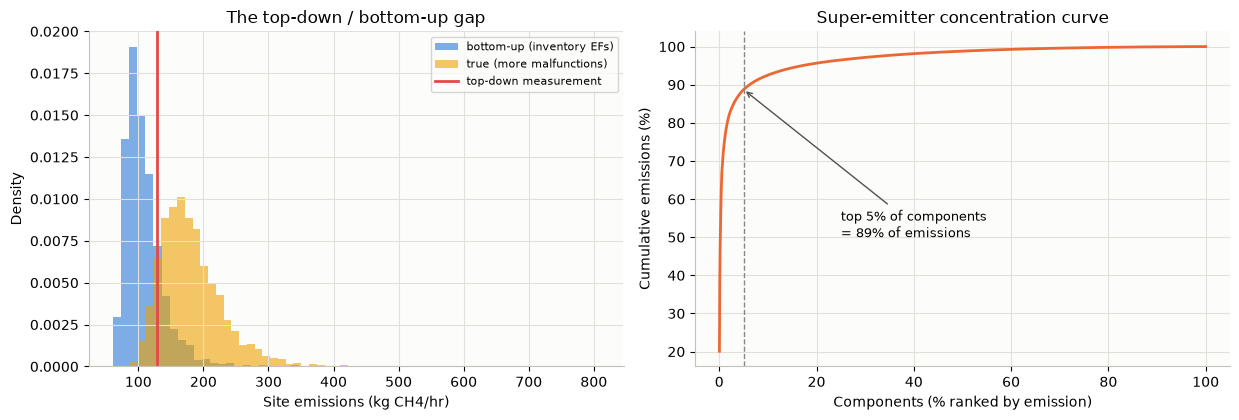

In [4]:
r = np.random.default_rng(7)
one_real = []
for _, row in INVENTORY.iterrows():
    base = r.lognormal(row.mu_ln, row.sd_ln, row["count"])
    malf = r.random(row["count"]) < np.clip(row.p_malf * TRUE_P_MALF_SCALE, 0, 1)
    vals = base * np.where(malf, row.malf_mult, 1.0)
    one_real += [(row.component, v) for v in vals]
comp = pd.DataFrame(one_real, columns=["component", "kg_hr"]).sort_values(
    "kg_hr", ascending=False).reset_index(drop=True)
comp["cum_share"] = comp.kg_hr.cumsum() / comp.kg_hr.sum()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
axes[0].hist(bottom_up, bins=60, density=True, alpha=0.6, color=PALETTE[0],
             label="bottom-up (inventory EFs)")
axes[0].hist(true_dist, bins=60, density=True, alpha=0.6, color=PALETTE[2],
             label="true (more malfunctions)")
axes[0].axvline(top_down_meas, color=PALETTE[5], lw=2, label="top-down measurement")
axes[0].set(xlabel="Site emissions (kg CH4/hr)", ylabel="Density",
            title="The top-down / bottom-up gap")
axes[0].legend(fontsize=8)

n_top = int(0.05 * len(comp))
axes[1].plot(np.arange(1, len(comp) + 1) / len(comp) * 100, comp.cum_share * 100,
             lw=2, color=PALETTE[7])
axes[1].axvline(5, ls="--", lw=1, color="#898781")
axes[1].annotate(f"top 5% of components\n= {comp.cum_share.iloc[n_top]:.0%} of emissions",
                 xy=(5, comp.cum_share.iloc[n_top] * 100), xytext=(25, 50),
                 fontsize=9, arrowprops=dict(arrowstyle="->", color="#52514e"))
axes[1].set(xlabel="Components (% ranked by emission)", ylabel="Cumulative emissions (%)",
            title="Super-emitter concentration curve")
plt.tight_layout()
plt.show()

## 4. Bayesian reconciliation of the malfunction rate

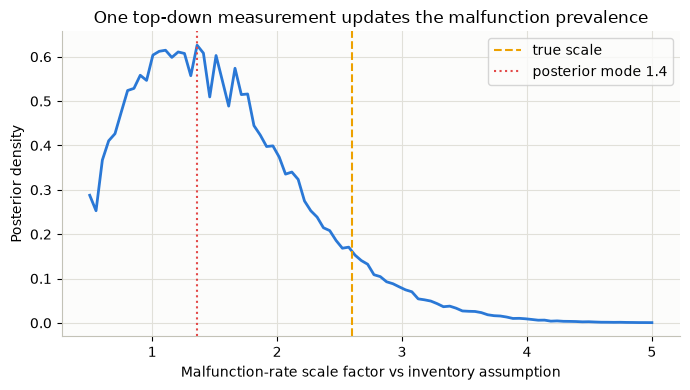

Reconciled inventory: 125 kg/hr (P10-P90 90-168) vs measurement 128


In [5]:
scales = np.linspace(0.5, 5, 90)
log_lik = []
for s in scales:
    dist = simulate_site(s, n=800, seed=int(s * 100))
    mu, sd = dist.mean(), np.sqrt(dist.std() ** 2 + (0.12 * top_down_meas) ** 2)
    log_lik.append(-0.5 * ((top_down_meas - mu) / sd) ** 2 - np.log(sd))
prior = -0.5 * ((scales - 1) / 1.5) ** 2          # weak prior centered on inventory
post = np.exp(np.array(log_lik) + prior)
post /= np.trapezoid(post, scales)
s_map = scales[np.argmax(post)]

plt.figure(figsize=(7, 4))
plt.plot(scales, post, lw=2, color=PALETTE[0])
plt.axvline(TRUE_P_MALF_SCALE, color=PALETTE[2], lw=1.5, ls="--", label="true scale")
plt.axvline(s_map, color=PALETTE[5], lw=1.5, ls=":", label=f"posterior mode {s_map:.1f}")
plt.xlabel("Malfunction-rate scale factor vs inventory assumption")
plt.ylabel("Posterior density")
plt.title("One top-down measurement updates the malfunction prevalence")
plt.legend()
plt.tight_layout()
plt.show()

reconciled = simulate_site(s_map, seed=9)
print(f"Reconciled inventory: {reconciled.mean():.0f} kg/hr "
      f"(P10-P90 {np.percentile(reconciled, 10):.0f}-{np.percentile(reconciled, 90):.0f}) "
      f"vs measurement {top_down_meas:.0f}")

## Conclusions

* The bottom-up/top-down gap emerges naturally from under-counted malfunction states —
  no fraud required, just fat tails plus optimistic component assumptions.
* The concentration curve is the mitigation strategy: ~5% of components carry the
  majority of emissions, so **find-and-fix beats fleet-wide polishing** on cost per
  tonne.
* A single quantified flyover, treated Bayesianly, recalibrates the whole inventory —
  the argument for combining continuous monitors with periodic campaigns.
* **Next step:** multi-measurement assimilation over time, and OGI survey optimization
  as an explicit search-theory problem over the tail.